# Customer Churn Analysis

## Project Overview
Is project mein Telco company ke customers ka 
data analyze kiya hai — kyun customers company 
chhod rahe hain.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("D:\\Dashboard by Python\\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Info
- Rows: 7,043 customers
- Columns: 21
- Source: Kaggle Telco Customer Churn

## "Data Exploration"

In [4]:
print(df.shape)

(7043, 21)


In [5]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## "Data Cleaning Code"

In [7]:
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [8]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [9]:
df["TotalCharges"] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [10]:
df.dropna(inplace=True)

In [11]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

## "Analysis — Churn Rate"
Overall churn rate **26.5%** hai — matlab har 
4 mein se 1 customer company chhod raha hai!

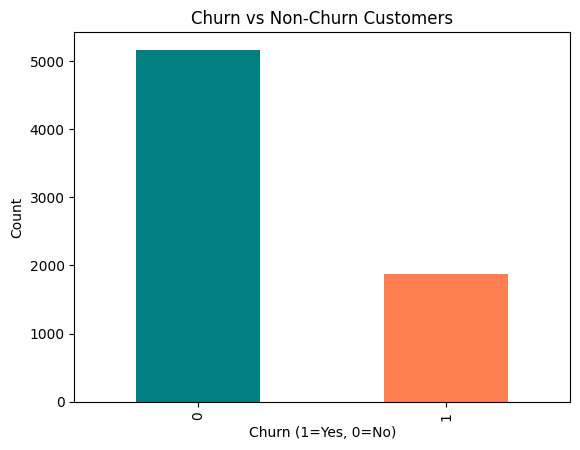

In [12]:
plt.Figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar', color= ["teal", "coral"])
plt.title('Churn vs Non-Churn Customers')
plt.xlabel('Churn (1=Yes, 0=No)')
plt.ylabel('Count')
plt.show()

## "Analysis — Contract Type"
- Month-to-month contract wale **42%** churn 
  karte hain
- 2 year contract wale sirf **2%** churn karte hain
- **Insight:** Long term contracts customer 
  retention ke liye best hain

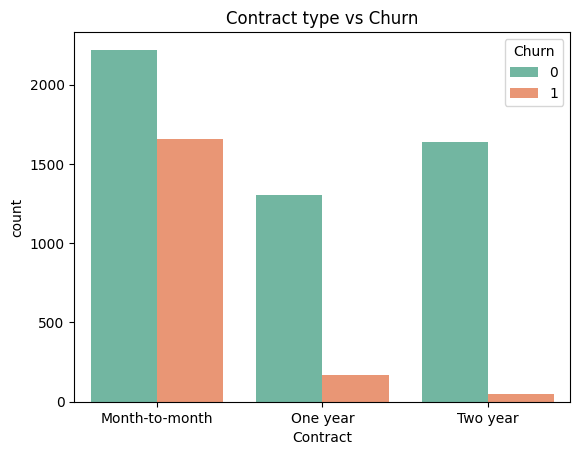

In [13]:
plt.Figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df, palette="Set2")
plt.title("Contract type vs Churn")
plt.show()

## "Analysis - Monthly Charges"
- Churned customers ka avg charges: **₹74/month**
- Non-churned customers ka avg: **₹61/month**
- **Insight:** Zyada charge = zyada churn risk

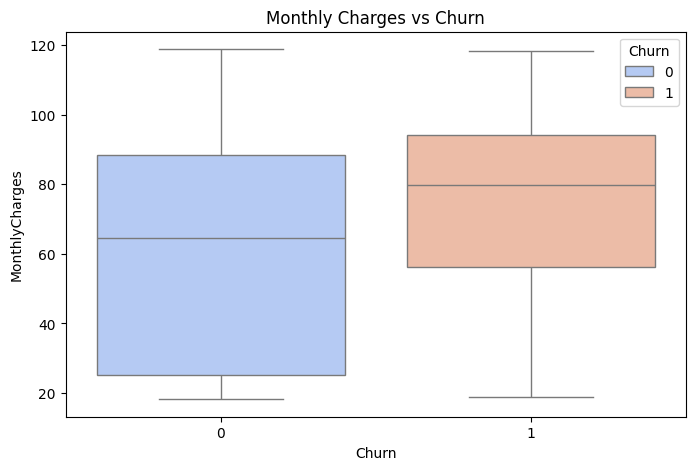

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, hue='Churn', palette='coolwarm')
plt.title('Monthly Charges vs Churn')
plt.show()

## "Analysis - Tenure"
- 0-12 months wale customers mein **47%** churn
- 48+ months wale mein sirf **15%** churn
- **Insight:** Naye customers sabse zyada 
  vulnerable hote hain

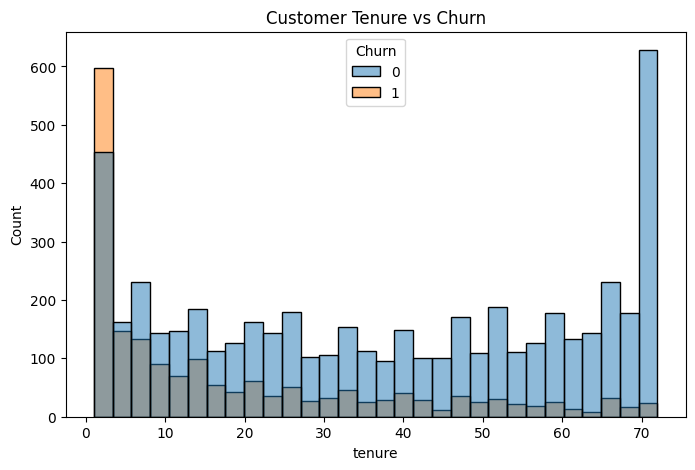

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)
plt.title('Customer Tenure vs Churn')
plt.show()

In [16]:
#1 Overall Churn Rate
churn_rate = df['Churn'].mean() * 100
print(f'Overall Churn Rate: {churn_rate:.2f}%')

# 2. Contract wise Churn %
print(df.groupby('Contract')['Churn'].mean()*100)

#3 Average Monthly Charges for Churned vs Non-Churned Customers
print(df.groupby('Churn')['MonthlyCharges'].mean())

# 4. Tenure wise Churn
new_customers = df[df['tenure'] <= 12]
print(f'New Customer Churn: {new_customers["Churn"].mean()*100:.2f}%')

Overall Churn Rate: 26.58%
Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64
Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64
New Customer Churn: 47.68%


# Conclusions & Recommendations

## Summary
Is analysis mein 7,043 Telco customers ka 
data explore kiya aur churn patterns dhundhe.

## Key Findings

1. **Overall Churn Rate: 26.5%**
   — Har 4 mein se 1 customer company chhod 
   raha hai

2. **Contract Type Sabse Bada Factor Hai**
   — Month-to-month customers 42% churn karte 
   hain vs 2-year contract wale sirf 3%

3. **Zyada Charges = Zyada Churn**
   — Churned customers average ₹74/month dete 
   the vs non-churned ₹61/month

4. **Naye Customers Sabse Vulnerable**
   — 0-12 months tenure wale 47% churn karte 
   hain

## Recommendations

1. Month-to-month customers ko long-term 
   contract offers karo — discounts do
2. High charges wale customers ko loyalty 
   benefits do
3. Naye customers ke liye special onboarding 
   program banao — pehle 6 months critical hain

## Tools Used
- Python, Pandas, Matplotlib, Seaborn
- Dataset: Kaggle Telco Customer Churn
- Rows: 7,043 | Columns: 21